<h1>Table of Contents<span class="tocSkip"></span></h1>
<div class="toc"><ul class="toc-item"><li><span><a href="#Load-Standard-Data-Science-Packages" data-toc-modified-id="Load-Standard-Data-Science-Packages-1"><span class="toc-item-num">1&nbsp;&nbsp;</span>Load Standard Data Science Packages</a></span></li><li><span><a href="#Load-&amp;-Visualize-Data" data-toc-modified-id="Load-&amp;-Visualize-Data-2"><span class="toc-item-num">2&nbsp;&nbsp;</span>Load &amp; Visualize Data</a></span><ul class="toc-item"><li><span><a href="#Pure-Amplification-Curves" data-toc-modified-id="Pure-Amplification-Curves-2.1"><span class="toc-item-num">2.1&nbsp;&nbsp;</span>Pure Amplification Curves</a></span></li><li><span><a href="#Pure-Melting-Peak-Distributions" data-toc-modified-id="Pure-Melting-Peak-Distributions-2.2"><span class="toc-item-num">2.2&nbsp;&nbsp;</span>Pure Melting Peak Distributions</a></span></li><li><span><a href="#Mixture-Data" data-toc-modified-id="Mixture-Data-2.3"><span class="toc-item-num">2.3&nbsp;&nbsp;</span>Mixture Data</a></span></li></ul></li><li><span><a href="#FFI-Multiplexing" data-toc-modified-id="FFI-Multiplexing-3"><span class="toc-item-num">3&nbsp;&nbsp;</span>FFI Multiplexing</a></span><ul class="toc-item"><li><span><a href="#Cross-Validation-on-Pure-Data" data-toc-modified-id="Cross-Validation-on-Pure-Data-3.1"><span class="toc-item-num">3.1&nbsp;&nbsp;</span>Cross-Validation on Pure Data</a></span></li></ul></li><li><span><a href="#ACA-Multiplexing" data-toc-modified-id="ACA-Multiplexing-4"><span class="toc-item-num">4&nbsp;&nbsp;</span>ACA Multiplexing</a></span><ul class="toc-item"><li><span><a href="#Cross-Validation-on-Pure-Data" data-toc-modified-id="Cross-Validation-on-Pure-Data-4.1"><span class="toc-item-num">4.1&nbsp;&nbsp;</span>Cross-Validation on Pure Data</a></span></li><li><span><a href="#Effect-of-the-volume-of-training-data" data-toc-modified-id="Effect-of-the-volume-of-training-data-4.2"><span class="toc-item-num">4.2&nbsp;&nbsp;</span>Effect of the volume of training data</a></span></li><li><span><a href="#Distribution-of-Targets-in-Loaded-Panels-(for-MCA-and-ACA)" data-toc-modified-id="Distribution-of-Targets-in-Loaded-Panels-(for-MCA-and-ACA)-4.3"><span class="toc-item-num">4.3&nbsp;&nbsp;</span>Distribution of Targets in Loaded Panels (for MCA and ACA)</a></span></li><li><span><a href="#Train-on-Pure,-Test-on-All-Combinations-(Different-Digital-Chip)" data-toc-modified-id="Train-on-Pure,-Test-on-All-Combinations-(Different-Digital-Chip)-4.4"><span class="toc-item-num">4.4&nbsp;&nbsp;</span>Train on Pure, Test on All Combinations (Different Digital Chip)</a></span></li></ul></li></ul></div>

# Load Standard Data Science Packages

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import itertools
sns.set()
sns.set_style("whitegrid")
sns.set_style("ticks")

# Set suitable default colours for colorblind
import matplotlib as mpl
from cycler import cycler
from matplotlib.colors import to_hex
wong_palette_10 = [
    (0, 0.45, 0.70),    # Blue
    (0.9, 0.6, 0.0),    # Orange
    (0.0, 0.60, 0.50),  # Bluish Green
    (0.8, 0.4, 0),      # Vermillion
    (0.35, 0.7, 0.9),   # Sky Blue
    (0.8, 0.6, 0.7),    # Reddish Purple
    (0.5, 0.5, 0.5),    # Gray
    (0.95, 0.9, 0.25),  # Yellow
    (0.5, 0.2, 0.5),    # Deep Purple (New)
    (0.6, 0.1, 0.1)     # Dark Red (New)
]

mpl.rcParams['axes.prop_cycle'] = cycler(color=[to_hex(i) for i in wong_palette_10])


#############################
# Import utility packages
#############################
from tqdm.auto import tqdm
from pathlib import Path
import dill as pickle
from collections import OrderedDict
from functools import reduce
import utilities as utils

#############################
# Import Machine Learning Tools
#############################
from sklearn.neighbors import KNeighborsClassifier, KernelDensity
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsOneClassifier
from sklearn.model_selection import StratifiedKFold, StratifiedShuffleSplit
from sklearn.preprocessing import LabelEncoder

#############################
# Set constants
#############################
DPI = 100 # This is the quality of figures

/Users/kautsarg/Library/CloudStorage/OneDrive-ImperialCollegeLondon/Final Project/3. Initial code/titan-signal-processing-main/venv_titan/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Load & Visualize Data

## Pure Amplification Curves

In [2]:
exp_folder = "/Users/kautsarg/Library/CloudStorage/OneDrive-ImperialCollegeLondon/Final Project/Run Data/trial test data/"
exp_path = Path(exp_folder, "D20250808_E00_C00_F4500KHz_U_Sample_7")
sigmoid_data_path = f'{exp_path}/normalised_ori_ac_df.csv'

chip_data = pd.read_csv(sigmoid_data_path)
chip_data.head()

,row_min,row_max,row_range,well,Cycle71.10000000000001,Cycle74.89999999999999,Cycle78.7,Cycle82.49999999999999,Cycle86.3,Cycle90.10000000000001,...,Cycle2364.4,Cycle2368.2000000000003,Cycle2372.0,Cycle2375.8,Cycle2379.6000000000004,Cycle2383.4,Cycle2387.1000000000004,Cycle2390.9,Cycle2394.7000000000003,Cycle2398.5
0,0.209451,0.239304,0.029854,0,0.349434,0.540309,0.387931,0.460512,0.580866,0.365884,...,0.941709,0.809183,0.909720,0.922483,0.852831,0.840307,0.916096,0.935289,0.967503,0.802990
1,0.197048,0.227095,0.030047,0,0.759950,0.960076,0.861983,0.747378,0.709898,0.587455,...,0.887906,0.868448,0.842652,0.741107,0.617715,0.913998,0.817022,0.946856,0.894413,0.979988
2,0.190823,0.223456,0.032633,0,0.890486,0.749545,0.848796,0.896482,0.836974,0.647404,...,0.926616,0.872559,0.993826,0.801743,0.926616,0.920568,0.932673,0.963118,0.932673,1.000000
3,0.201863,0.221085,0.019222,0,0.937447,0.868949,0.708686,1.000000,0.896223,0.741607,...,0.643558,0.702131,0.695585,0.754843,0.572990,0.617769,0.592126,0.748220,0.662998,0.466061
4,0.203428,0.228837,0.025409,0,0.647595,0.790119,0.622941,0.739258,0.739258,0.315044,...,0.955395,0.867592,0.902492,0.841607,0.867592,0.832981,1.000000,0.893739,0.867592,0.885005


In [3]:
chip_data.shape

(12047, 619)

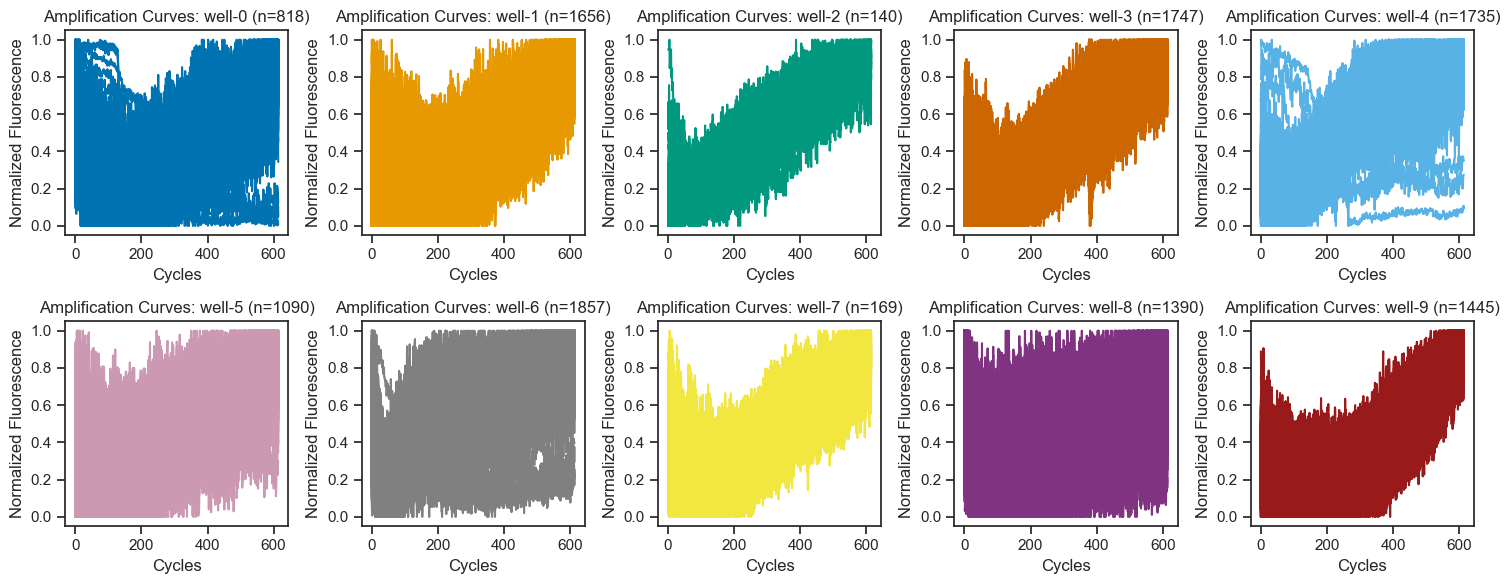

In [4]:
targets = chip_data.well.unique()
names = list("well-" + targets.astype(str))
colors = list("C" + targets.astype(str))
data = chip_data
data_type = 'AC'
xlabel = 'Cycles'
ylabel = 'Normalized Fluorescence'
title = 'Amplification Curves'

plot_rows = 2
plot_cols = int(len(targets)/plot_rows)
fig, ax = plt.subplots(plot_rows, plot_cols, dpi=DPI, figsize=(plot_cols*3, plot_rows*3))
for i, (target, name, color) in enumerate(zip(targets, names, colors)):
    c = i%plot_cols
    r = i//plot_cols
    utils.plot_curves(ax[r][c], data, target, name, color, data_type, xlabel, ylabel, title)
    
plt.tight_layout()
plt.show()

## Pure Melting Peak Distributions

In [5]:
print("N/A")
# targets = ['NDM', 'VIM', 'KPC']
# names = ['$bla_{NDM}$', '$bla_{VIM}$', '$bla_{KPC}$']
# colors = ['C0', 'C1', 'C2']

# fig, ax = plt.subplots(1, 1, dpi=DPI, figsize=(15, 3))
# for i, (target, name, color) in enumerate(zip(targets, names, colors)):
#     df_single_target = data[data.MeltLabels==target]
#     peaks =  np.concatenate(df_single_target.MeltPeak.values)
    
#     sns.distplot(peaks, bins=100, ax=ax, color=color,
#                  hist_kws={'alpha': 1, 'linewidth': 0.},
#                  kde_kws={'color': 'k'},
#                  label=target, norm_hist=True)
    
#     kde = KernelDensity(kernel='gaussian', bandwidth=0.05).fit(peaks.reshape(-1, 1)) #you can supply a bandwidth
#     x = np.linspace(80,95,1000)[:, np.newaxis]
#     log_density_values = kde.score_samples(x)
#     density = np.exp(log_density_values)
#     max_likelihood = x[density.argmax()]
#     ax.text(max_likelihood+0.1, 3, name, color=color, weight='bold', fontsize=16)
    
# ax.set_xlabel('Temperature')
# ax.set_ylabel('Normalized Distribution')
# plt.tight_layout()
# plt.show()

N/A


## Mixture Data

In [6]:
# dPCR_mixture = pd.read_csv('Data/dPCR_Dataset_Mixture.csv', index_col=0)
# dPCR_mixture.MeltPeak = [eval(' '.join(i.split()).replace(' ', ',')) for i in dPCR_mixture.MeltPeak]
# dPCR_mixture.head()
print("N/A")

N/A


# FFI Multiplexing

## Cross-Validation on Pure Data

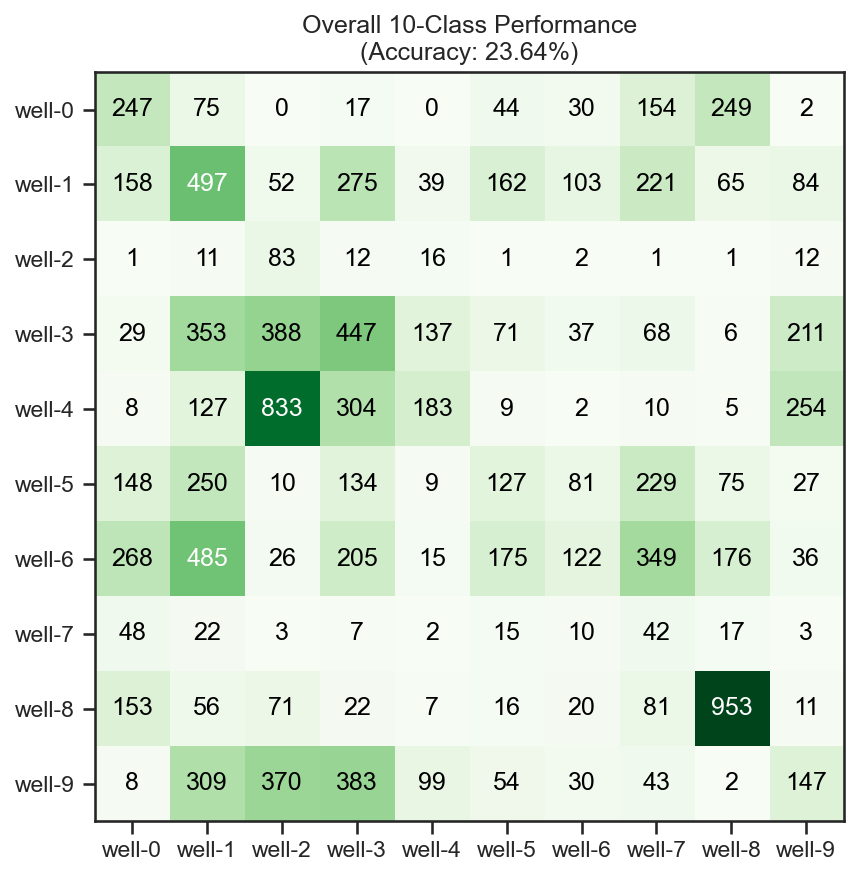

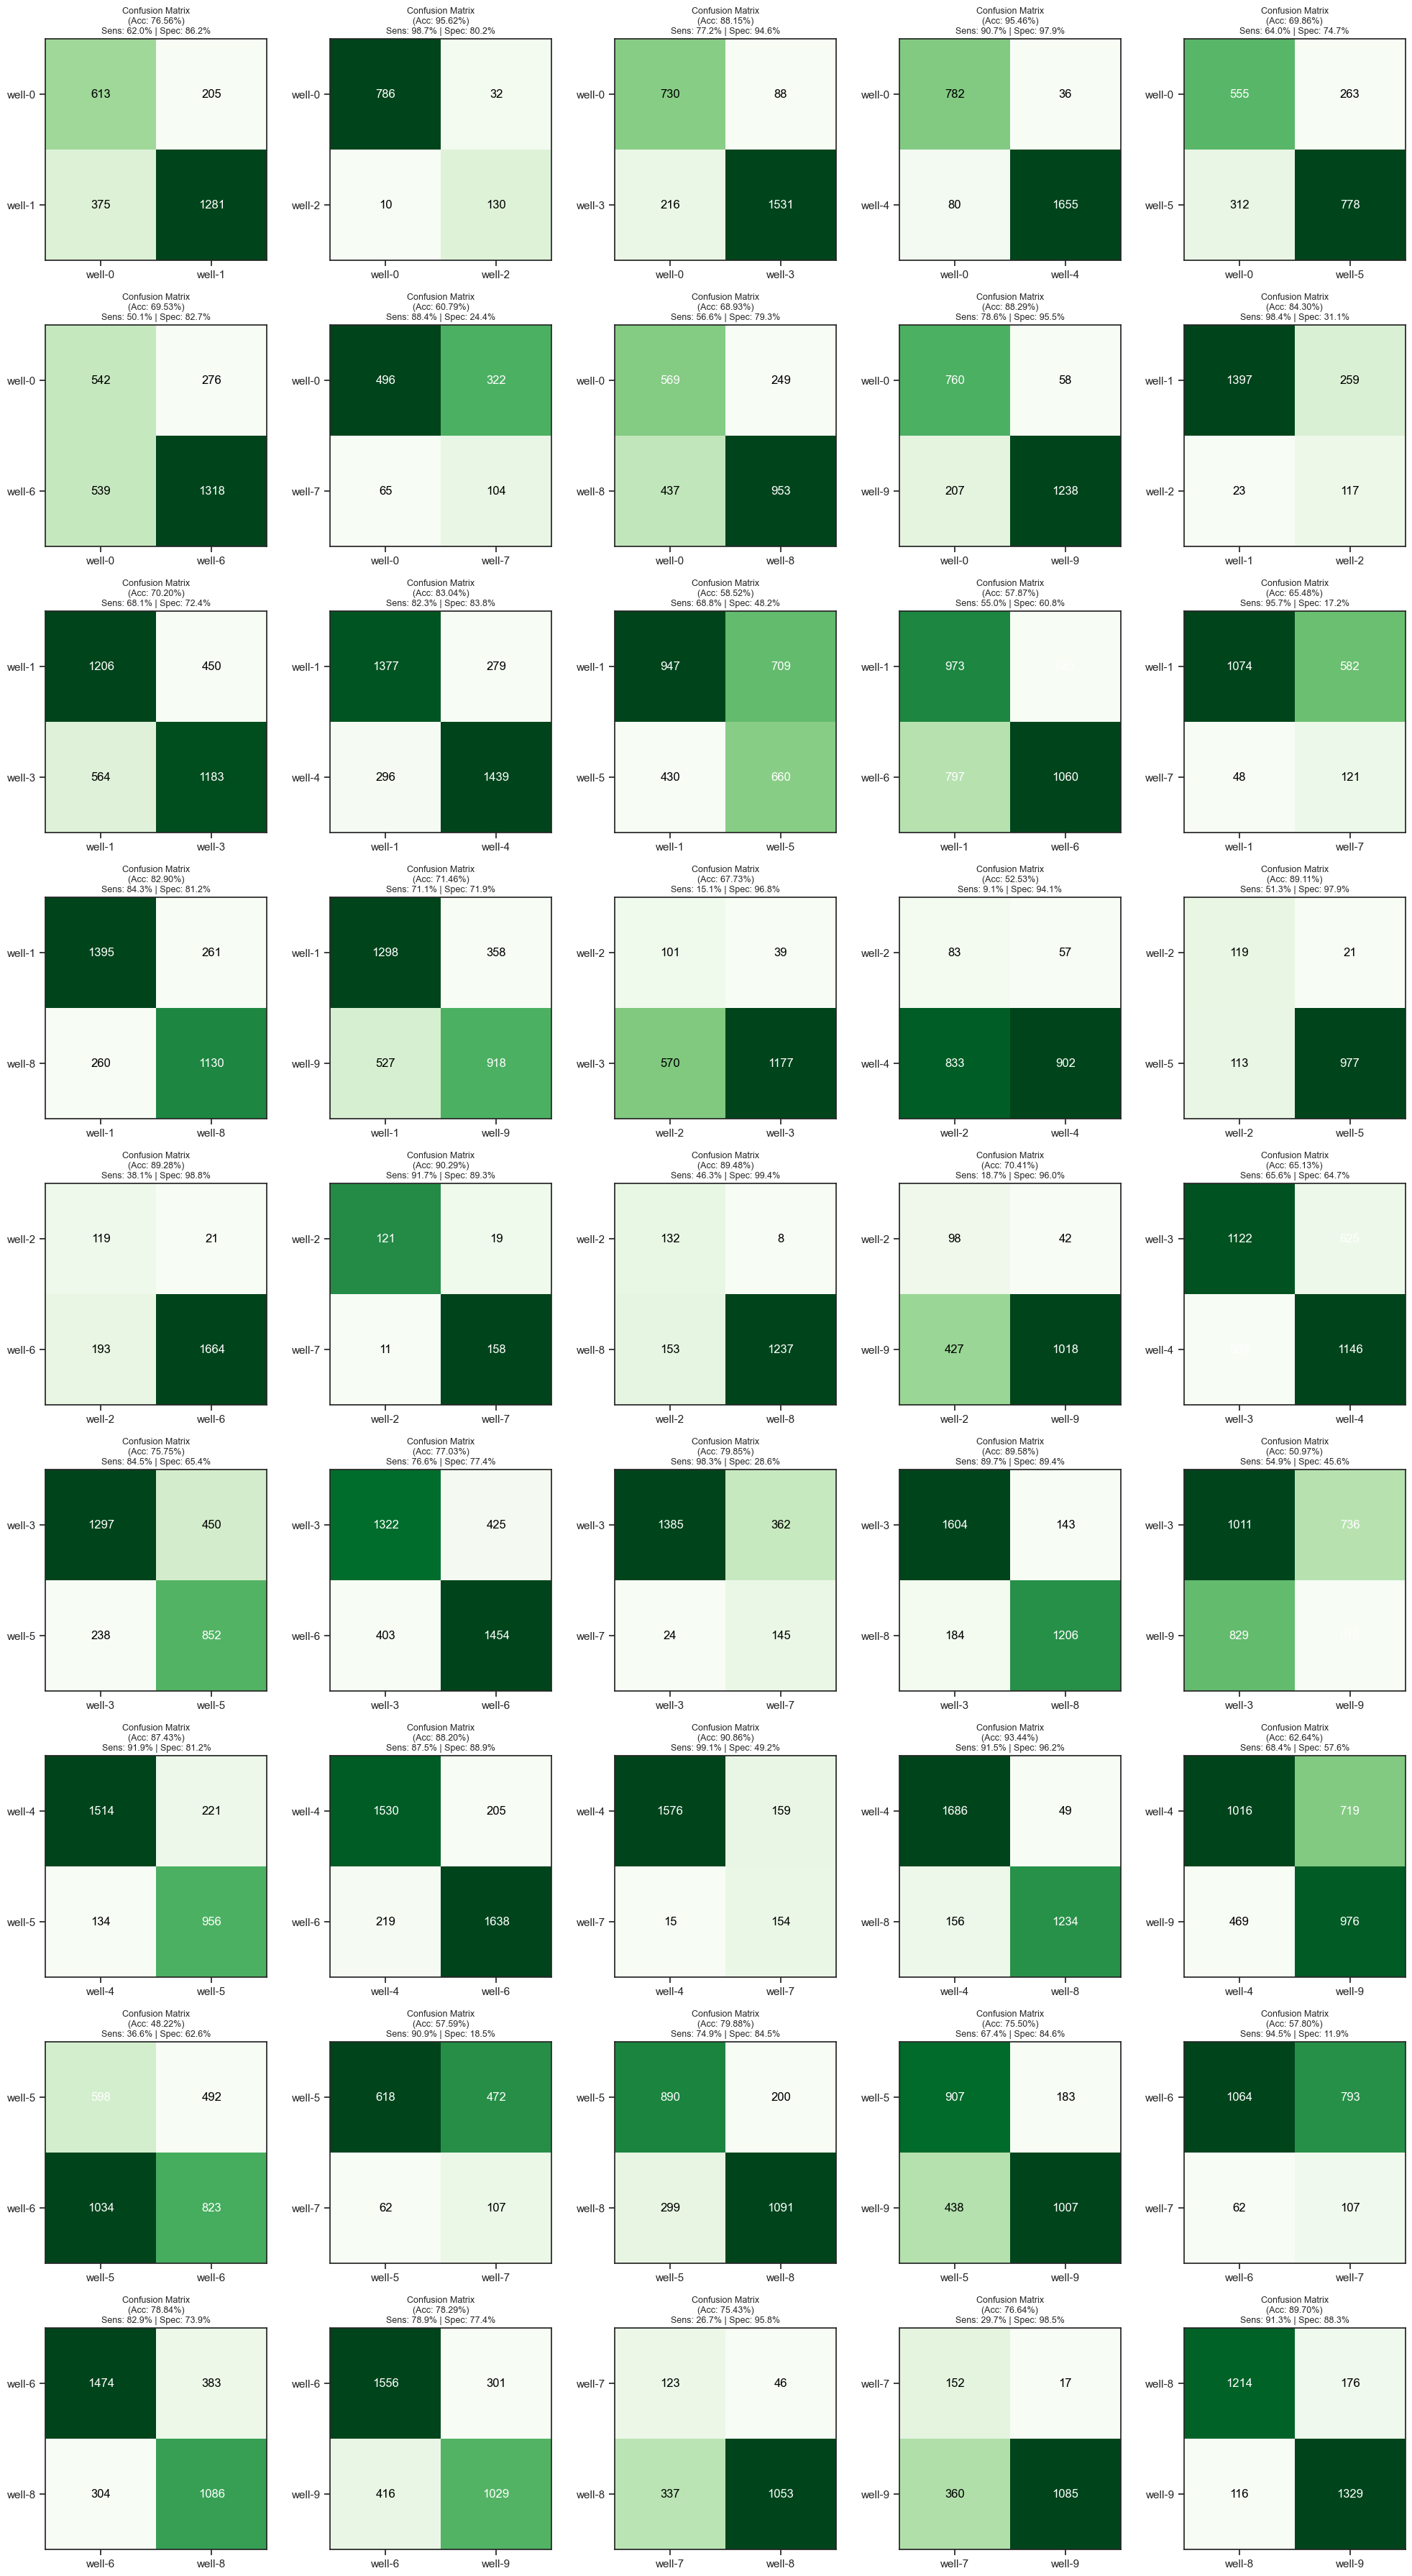

In [7]:
X_raw = utils.unnormalized(chip_data).filter(like='Cycle').values
y_raw = chip_data.well.values

le = LabelEncoder()
y = le.fit_transform(y_raw)

n_labels = len(np.unique(y))
X_new = X_raw[:, -1].reshape(-1, 1)

# Fix 'targets' NameError
names = ["well-" + str(target) for target in le.classes_]
combinations = list(itertools.combinations(range(n_labels), 2))

clf = OneVsOneClassifier(LogisticRegression(class_weight='balanced'))
folds = StratifiedKFold(n_splits=10, shuffle=True, random_state=0)

true_each_fold = []
pred_each_fold = []

for train_index, test_index in folds.split(X_new, y):
    X_train, X_test = X_new[train_index], X_new[test_index]
    y_train, y_test = y[train_index], y[test_index]
    
    clf.fit(X_train, y_train)

    all_labels = tuple(range(n_labels))
    preds = {all_labels: clf.predict(X_test)}
    trues = {all_labels: y_test}

    for model, features in zip(clf.estimators_, combinations):
        i, j = features 
        
        mask = (y_test == i) | (y_test == j)
        X_subset = X_test[mask]
        
        if len(X_subset) > 0:
            binary_preds = model.predict(X_subset)
            preds[features] = np.where(binary_preds == 0, i, j)
            trues[features] = y_test[mask]
        else:
            preds[features] = np.array([])
            trues[features] = np.array([])
        
    pred_each_fold.append(preds)
    true_each_fold.append(trues)

all_labels = tuple(range(n_labels))
y_true_global = np.concatenate([fold[all_labels] for fold in true_each_fold])
y_pred_global = np.concatenate([fold[all_labels] for fold in pred_each_fold])
accuracy = 100 * np.mean(y_true_global == y_pred_global)

fig, ax = plt.subplots(figsize=(6, 6), dpi=150)
utils.plot_(all_labels, ax, true_each_fold, pred_each_fold, names)

plt.title(f"Overall 10-Class Performance\n(Accuracy: {accuracy:.2f}%)")
plt.tight_layout()
plt.show()

cols = 5 
rows = (len(combinations) // cols) + (1 if len(combinations) % cols != 0 else 0)

fig, axes = plt.subplots(rows, cols, figsize=(cols * 4, rows * 4), dpi=100)
axes = axes.flatten()

for i, features in enumerate(combinations):
    utils.plot_(features, axes[i], true_each_fold, pred_each_fold, names)
    
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [8]:
print(len(true_each_fold))
x = [item[(0,1)] for item in true_each_fold]
print([len(a) for a in x])
print(len(np.concatenate(x)))

10
[248, 248, 248, 248, 247, 247, 247, 247, 247, 247]
2474


/Users/kautsarg/Library/CloudStorage/OneDrive-ImperialCollegeLondon/Final Project/3. Initial code/titan-signal-processing-main/venv_titan/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1281: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


AttributeError: module 'numpy' has no attribute 'uniue'

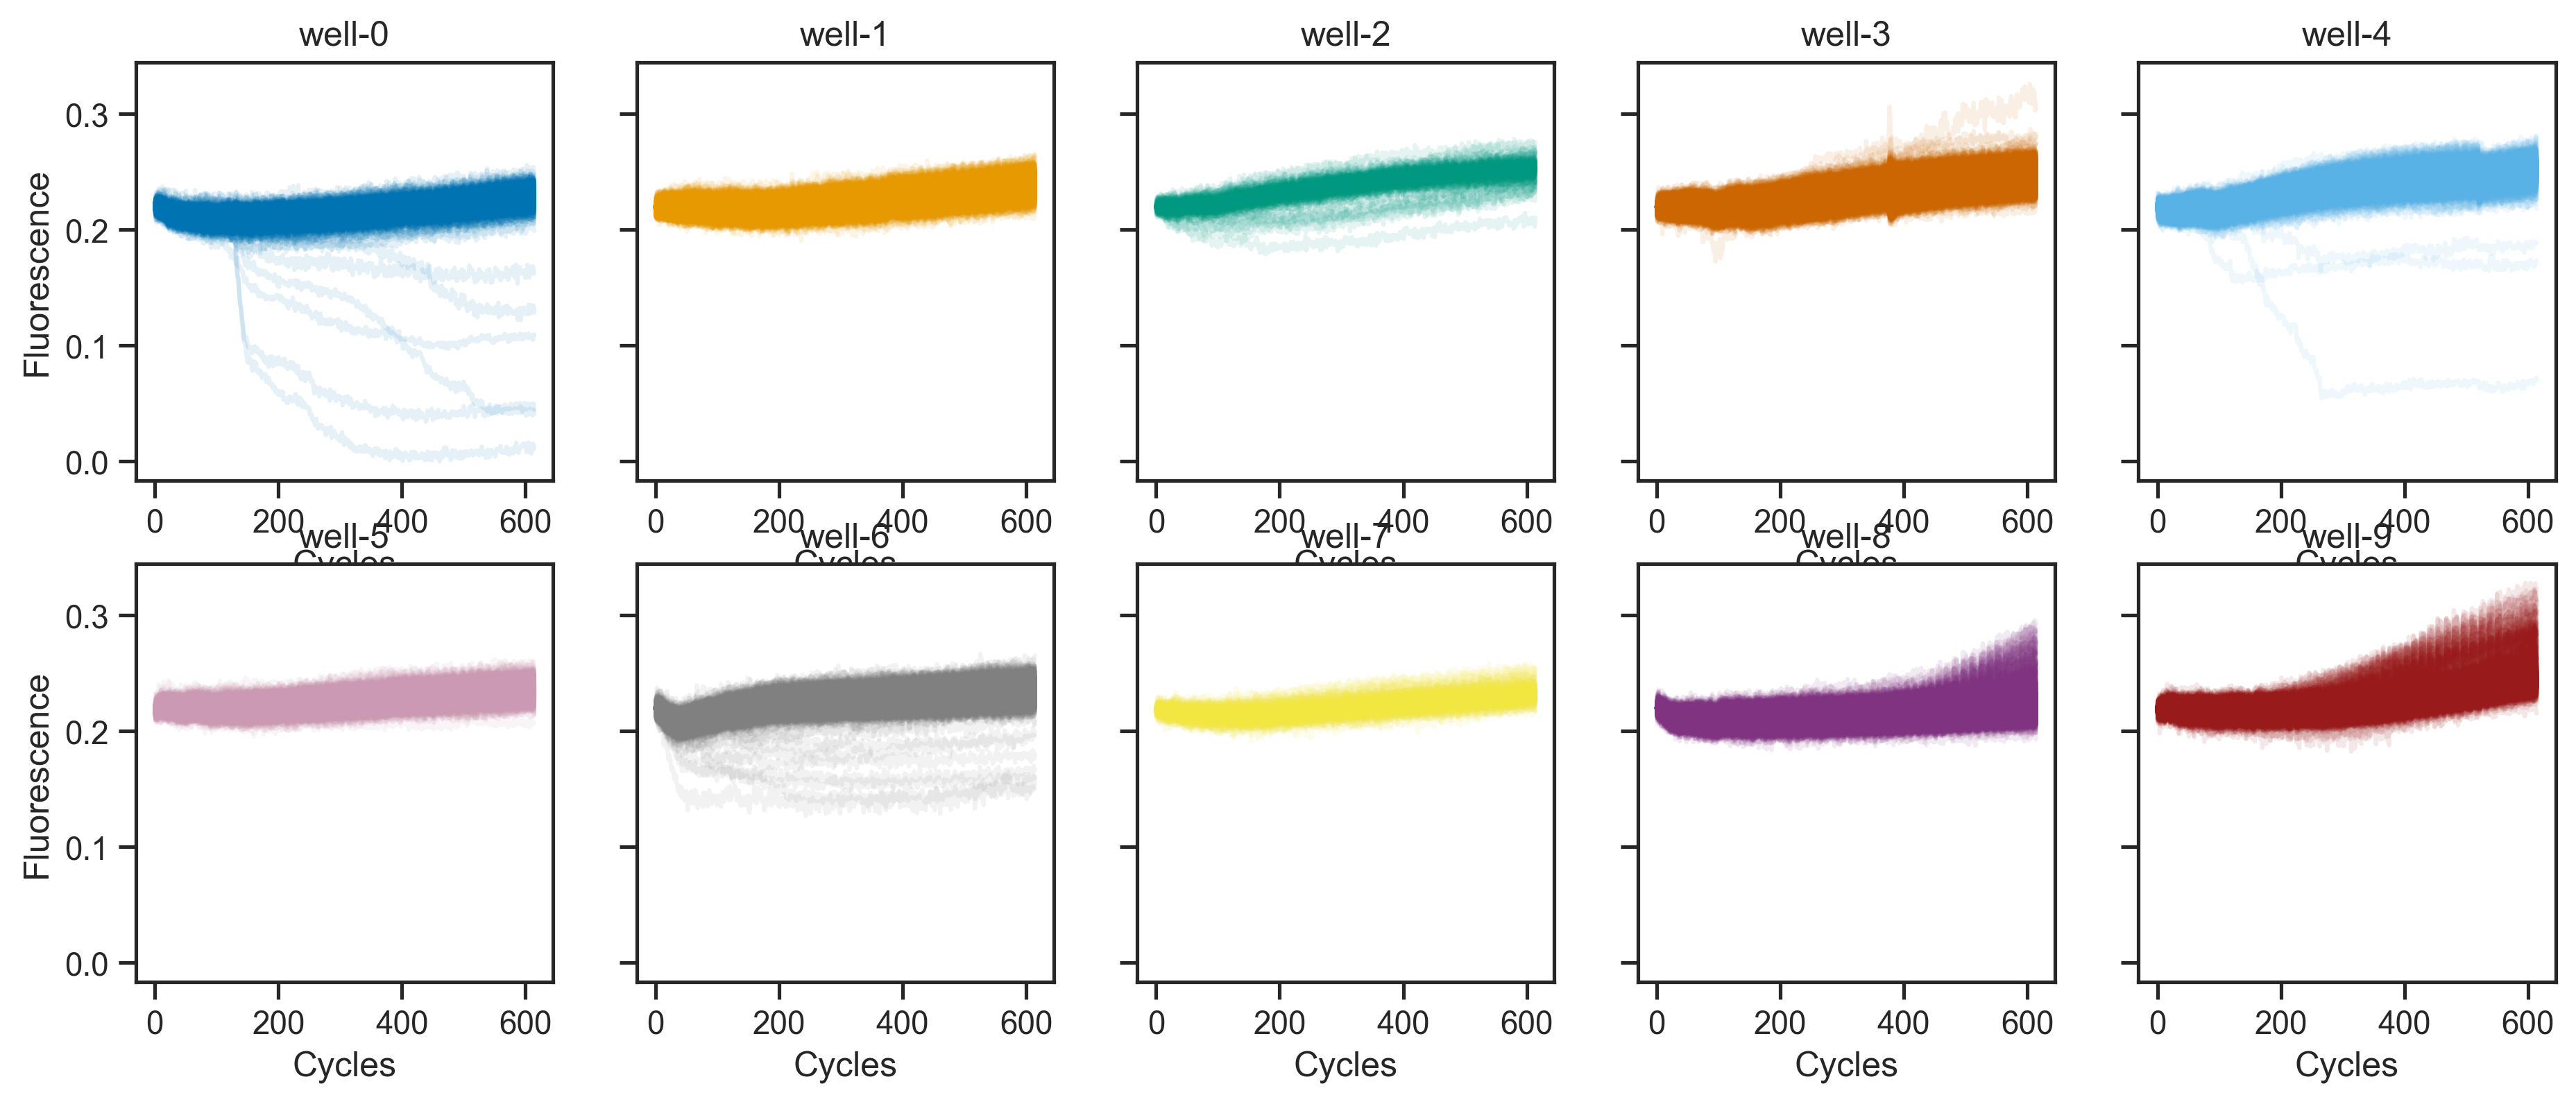

In [9]:
import matplotlib.gridspec as gridspec

X = utils.unnormalized(chip_data).filter(like='Cycle').values
y_raw = chip_data.well.values

le = LabelEncoder()
y = le.fit_transform(y_raw)
n_labels = len(np.unique(y))
names = ["well-" + str(c) for c in le.classes_]

X_new = X[:, -1].reshape(-1, 1) # Final Fluorescent Intensity (FFI)

# 2. Setup Figure and GridSpec for 10 classes
fig = plt.figure(figsize=(15, 12), dpi=300)
gs = gridspec.GridSpec(ncols=5, nrows=4)

# 3. Plot the 10 separate curve subplots
first_ax = None # Variable to store the first axis

for i in range(n_labels):
    row = i // 5  
    col = i % 5   
    
    # If it's the very first plot, create it normally
    if first_ax is None:
        ax = fig.add_subplot(gs[row, col])
        first_ax = ax
    # For all subsequent plots, link their y-axis to the first plot
    else:
        ax = fig.add_subplot(gs[row, col], sharey=first_ax)
        
    ax.plot(X[y==i, :].T, color=f'C{i}', alpha=0.1) 
    ax.set_title(names[i])
    ax.set_xlabel('Cycles')
    
    # Only show the y-axis label and tick numbers on the leftmost column
    if col == 0:
        ax.set_ylabel('Fluorescence')
    else:
        ax.tick_params(labelleft=False) # Hides the tick numbers for inner columns

# 4. Modeling to find the thresholds
clf = LogisticRegression(class_weight='balanced', multi_class='ovr')
clf.fit(X_new, y)

# Generate a high-res line of predictions to find where classes shift
x_pred = np.linspace(X_new.min(), X_new.max(), num=10000).reshape(-1, 1)
preds = clf.predict(x_pred)

# Find transition points (Thresholds T1 through T9)
thresholds = []
for i in np.uniue(preds):
    # Find the first index where the prediction switches to class i
    idx = np.argmax(preds == i)
    print(i, idx)
    if idx > 0: # Ensure the class was actually predicted
        thresholds.append(x_pred[idx][0])

# 5. Plot the aggregated FFI scatter plot
ax_scatter = fig.add_subplot(gs[2:4, :])
cnt = 0

for i in range(n_labels):
    idx = y == i
    # Added alpha and reduced dot size (s=5) to handle the 12k+ points
    ax_scatter.scatter(np.arange(np.sum(idx)) + cnt, X_new[idx], color=f'C{i}', s=5, alpha=0.7)
    cnt += np.sum(idx)

# 6. Draw Thresholds
for t_idx, t_val in enumerate(thresholds):
    print(t_idx, t_val)
    ax_scatter.hlines(t_val, *ax_scatter.get_xlim(), colors='black', linestyles='dashed', alpha=0.7)
    # Placed text slightly outside the x-axis
    ax_scatter.text(len(X_new) * 1 + t_idx*150, t_val, f'T{t_idx+1}', color='black', verticalalignment='center', weight='bold')

# Adjust layout
ax_scatter.set_xlim((0, len(X_new) * 1.05)) # Make room for the threshold text
ax_scatter.set_ylabel('Final Fluorescent Intensity')
ax_scatter.set_xlabel('Event Number')

plt.tight_layout()
plt.subplots_adjust(hspace=0.5)
plt.show()

# ACA Multiplexing

In [10]:
from sklearn.manifold import TSNE

X_AC = utils.unnormalized(chip_data).filter(like='Cycle').values
AC_tsne = TSNE(n_components=2, init='random', learning_rate='auto', random_state=0, perplexity=500).fit_transform(X_AC)

/var/folders/xt/t6fw9lz91vg0ryq45tpjcjpc0000gn/T/ipykernel_52469/3609883741.py:5: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(AC_tsne[mask, 0], AC_tsne[mask, 1],


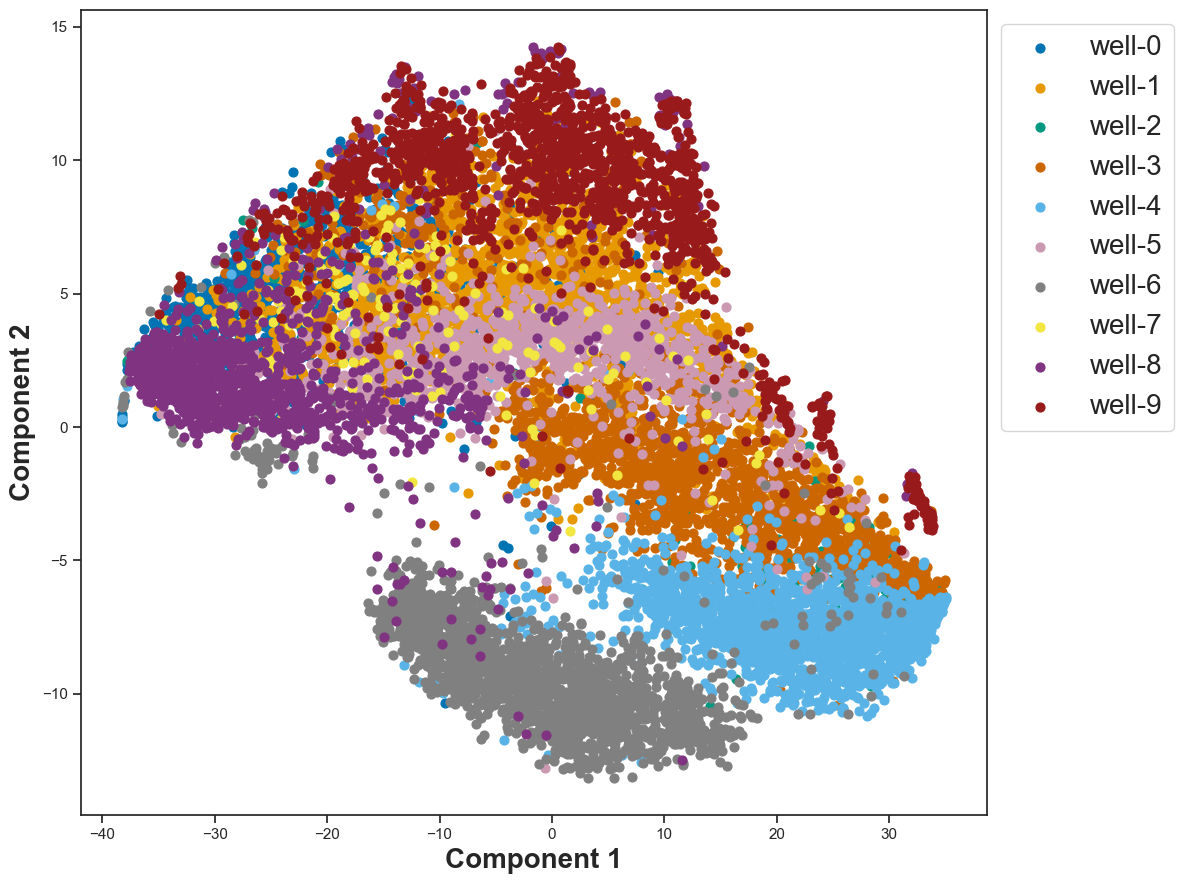

In [11]:
fig, ax = plt.subplots(figsize=(12, 9))

for label in range(10):
    mask = y == label
    ax.scatter(AC_tsne[mask, 0], AC_tsne[mask, 1],
               s=40, c=wong_palette_10[label], label=f"well-{label}")

ax.set_xlabel('Component 1', fontsize=20, fontweight='bold')
ax.set_ylabel('Component 2', fontsize=20, fontweight='bold')
# ax.set_title('t-SNE Visualization - Moving Average (25)', fontsize=24, fontweight='bold')
# ax.grid(True, alpha=0.3)
ax.legend(bbox_to_anchor=(1, 1), loc='upper left', fontsize=20)

plt.tight_layout()
plt.show()

## Cross-Validation on Pure Data

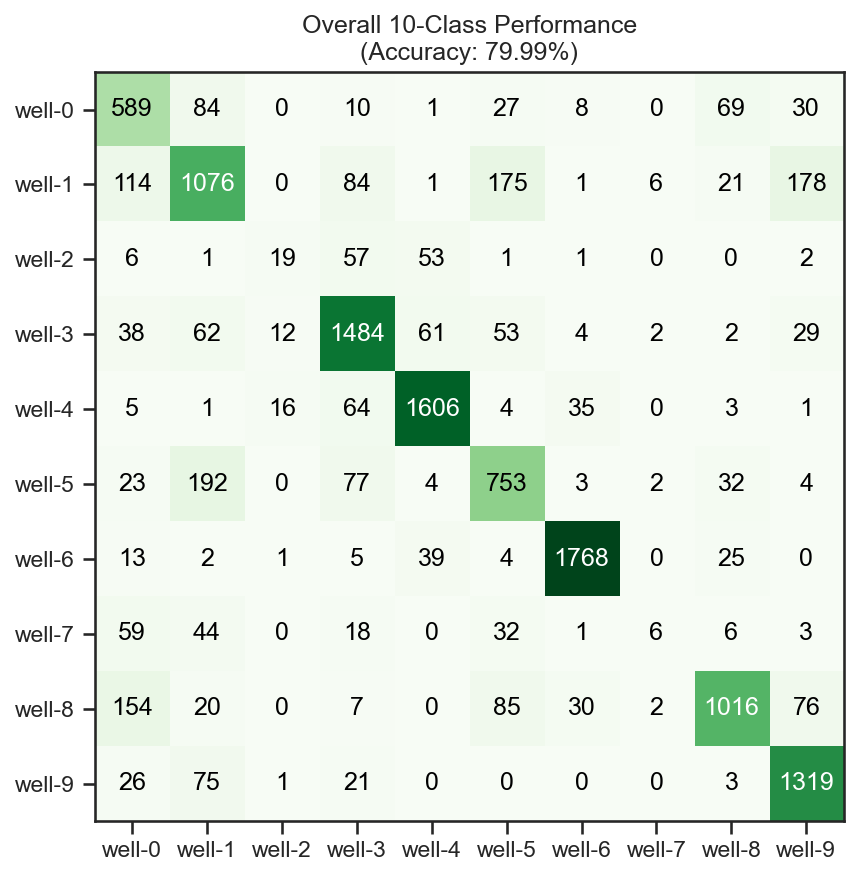

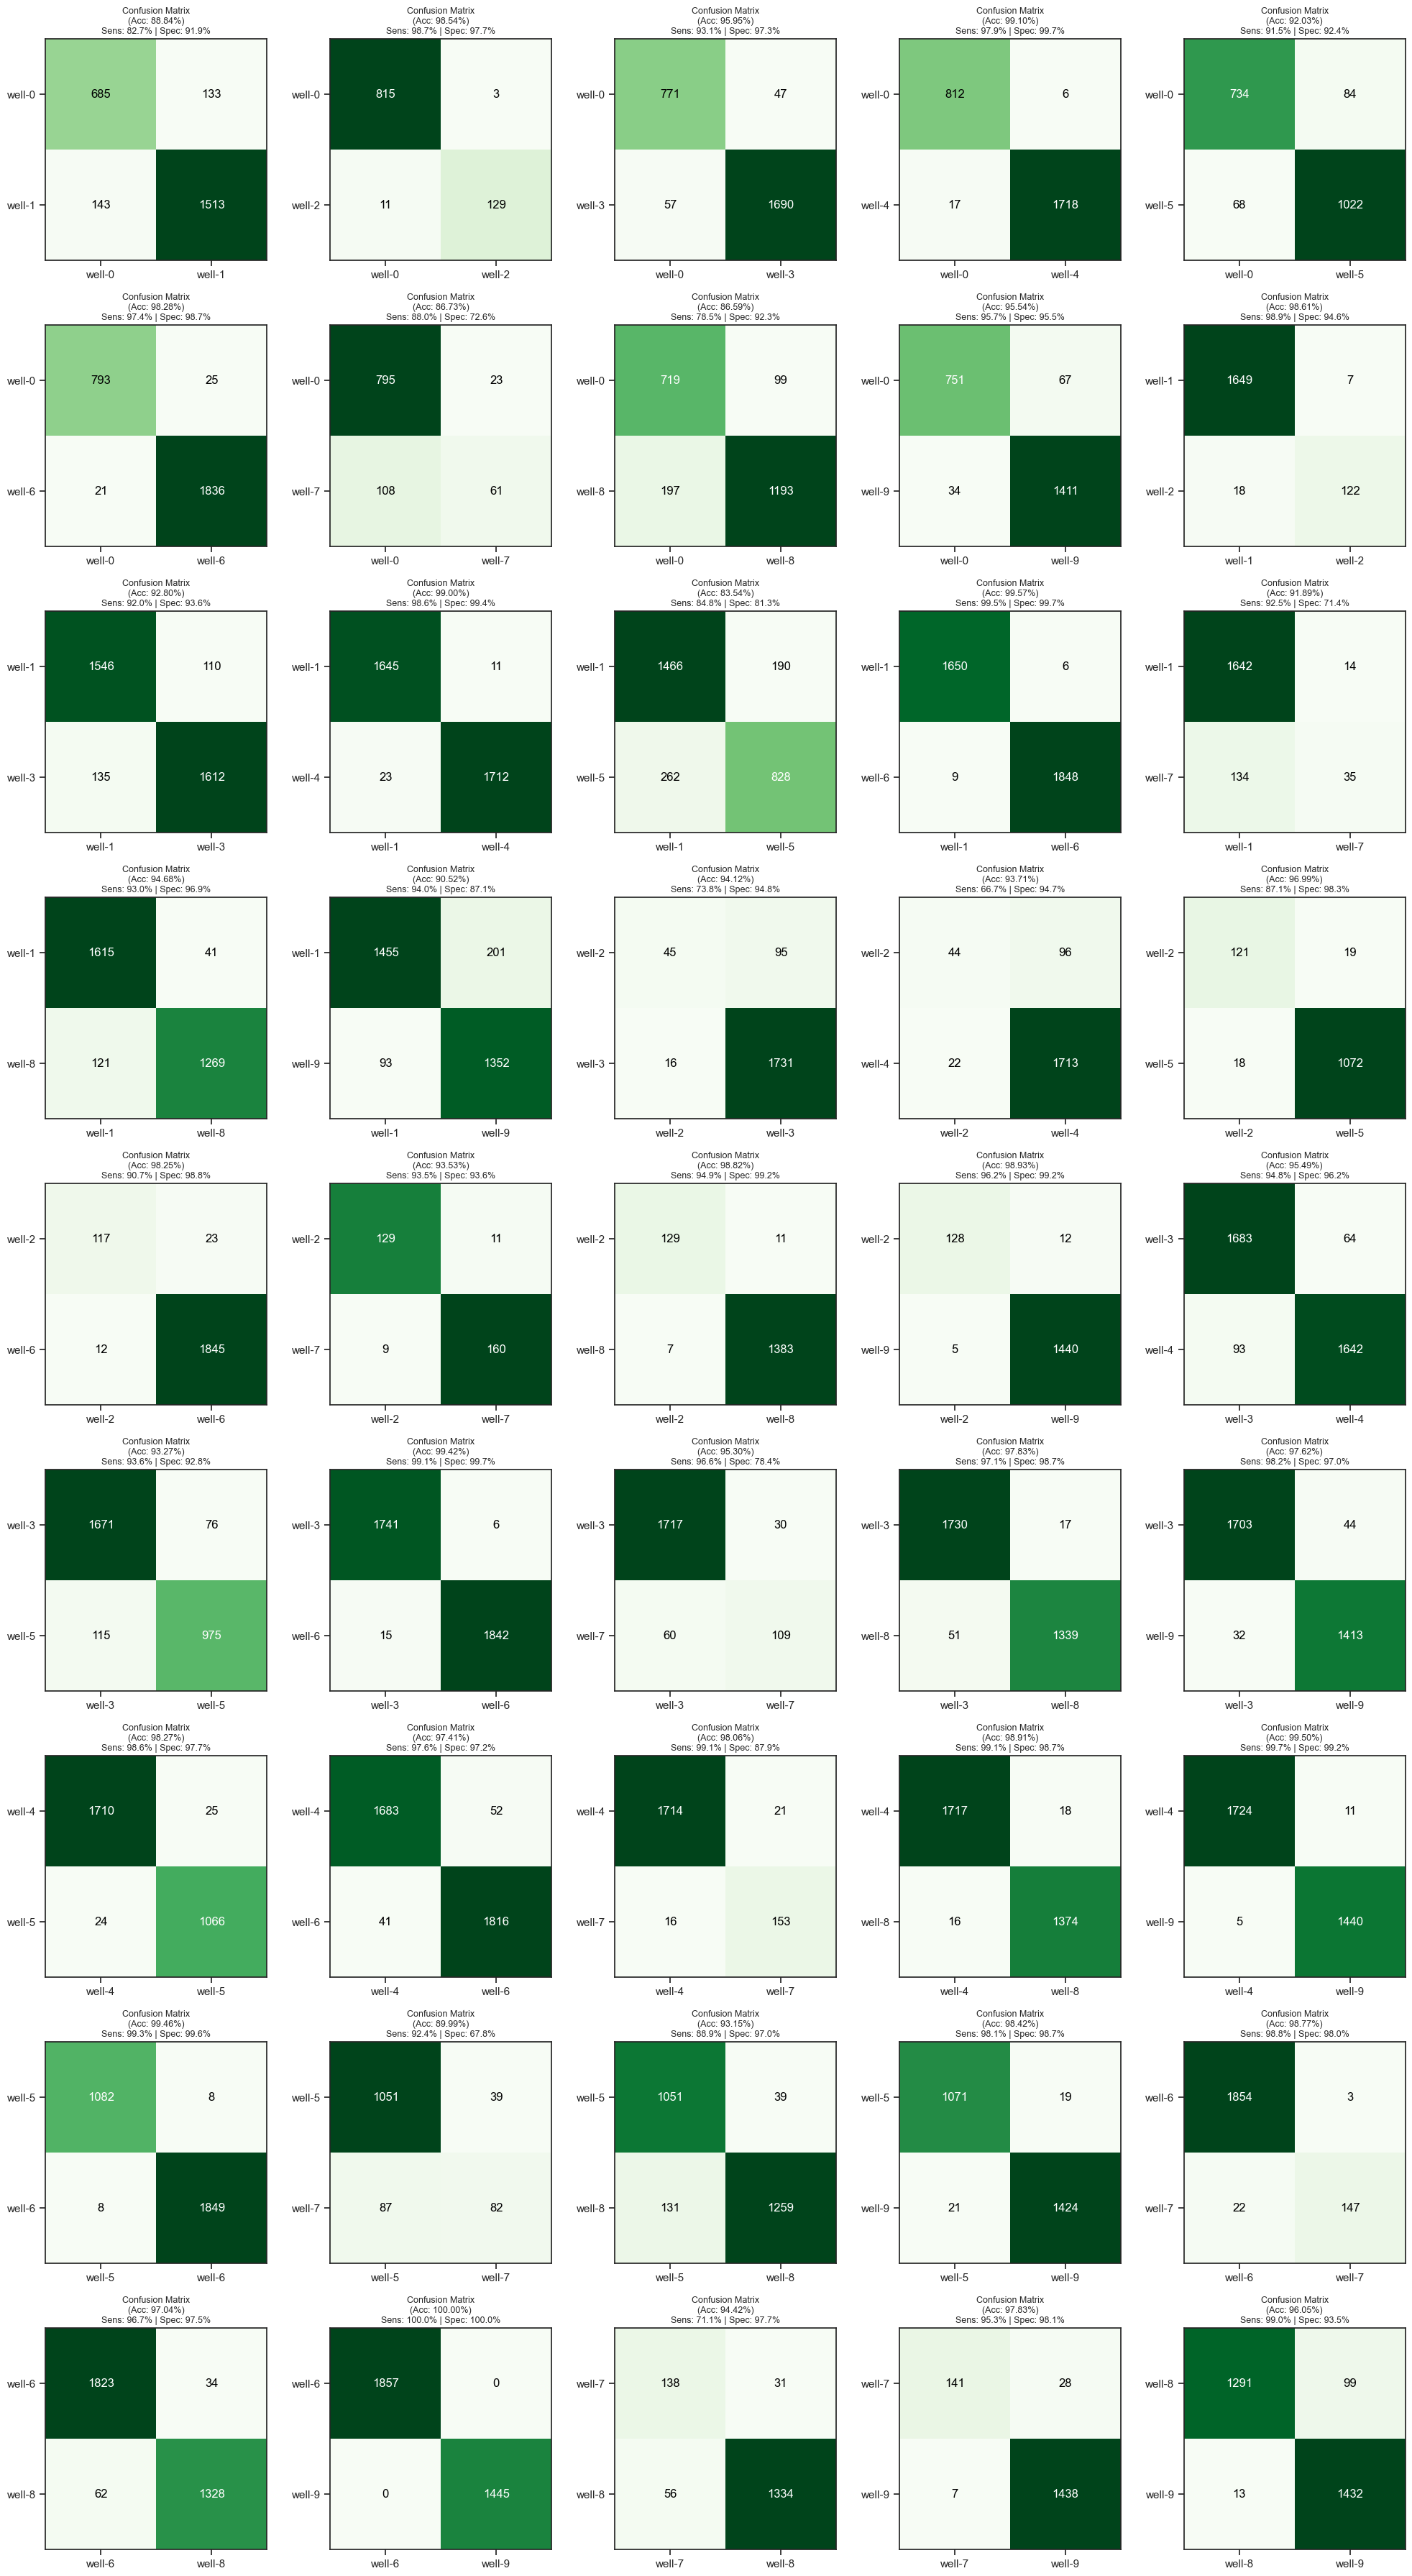

In [12]:
X_raw = utils.unnormalized(chip_data).filter(like='Cycle').values
y_raw = chip_data.well.values

le = LabelEncoder()
y = le.fit_transform(y_raw)
X_new = X_raw

N_NEIGHS = 10

n_labels = len(np.unique(y))
names = ["well-" + str(target) for target in le.classes_]

combinations = list(itertools.combinations(range(n_labels), 2))

clf = OneVsOneClassifier(KNeighborsClassifier(n_neighbors=N_NEIGHS))
folds = StratifiedKFold(n_splits=10, shuffle=True, random_state=0)

true_each_fold = []
pred_each_fold = []

for train_index, test_index in folds.split(X_new, y):
    X_train, X_test = X_new[train_index], X_new[test_index]
    y_train, y_test = y[train_index], y[test_index]
    
    clf.fit(X_train, y_train)
    
    all_labels = tuple(range(n_labels))
    preds = {all_labels: clf.predict(X_test)}
    trues = {all_labels: y_test}

    for model, features in zip(clf.estimators_, combinations):
        i, j = features 
        
        mask = (y_test == i) | (y_test == j)
        X_subset = X_test[mask]
        
        if len(X_subset) > 0:
            binary_preds = model.predict(X_subset)
            preds[features] = np.where(binary_preds == 0, i, j)
            trues[features] = y_test[mask]
        else:
            preds[features] = np.array([])
            trues[features] = np.array([])
        
    pred_each_fold.append(preds)
    true_each_fold.append(trues)


all_labels = tuple(range(n_labels))
y_true_global = np.concatenate([fold[all_labels] for fold in true_each_fold])
y_pred_global = np.concatenate([fold[all_labels] for fold in pred_each_fold])
accuracy = 100 * np.mean(y_true_global == y_pred_global)

fig, ax = plt.subplots(figsize=(6, 6), dpi=150)
utils.plot_(all_labels, ax, true_each_fold, pred_each_fold, names)

plt.title(f"Overall 10-Class Performance\n(Accuracy: {accuracy:.2f}%)")
plt.tight_layout()
plt.show()

cols = 5 
rows = (len(combinations) // cols) + (1 if len(combinations) % cols != 0 else 0)

fig, axes = plt.subplots(rows, cols, figsize=(cols * 4, rows * 4), dpi=100)
axes = axes.flatten()

for i, features in enumerate(combinations):
    utils.plot_(features, axes[i], true_each_fold, pred_each_fold, names)
    
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [11]:
len(X)

12047

## Effect of the volume of training data

In [23]:
n_splits = 100
n_train_sizes = 50
DESIRED_K = 10
test_size = 1000 / len(X)
train_sizes = np.logspace(-2, 0, num=n_train_sizes)

accuracy_list = [] 

for size in tqdm(train_sizes, desc='Train Size Split'):
    
    sss = StratifiedShuffleSplit(n_splits=n_splits, test_size=test_size, random_state=0)

    for split_id, (full_train_idx, test_index) in enumerate(sss.split(X, y)):
        
        subset_limit = int(len(full_train_idx) * size)
        train_index = full_train_idx[:subset_limit]
        
        X_train, X_test = X[train_index], X[test_index]
        y_train, y_test = y[train_index].ravel(), y[test_index].ravel()

        class_counts = np.bincount(y_train)
        active_counts = class_counts[class_counts > 0]
        
        if len(active_counts) < 2:
            # Cannot do One-vs-One with only 1 class present
            continue
            
        min_samples = np.min(active_counts)
        current_k = max(1, min(DESIRED_K, min_samples - 1))
        
        # Initialize neighbor with dynamic K
        neigh = OneVsOneClassifier(KNeighborsClassifier(n_neighbors=current_k))
        
        try:
            neigh.fit(X_train, y_train)
            
            # Record Train Accuracy
            accuracy_list.append({
                'TrainSize': len(X_train), 
                'Train/Test': 'Train',
                'Accuracy': 100 * np.mean(y_train == neigh.predict(X_train)), 
                'SplitID': split_id,
                'K_Used': current_k
            })

            # Record Test Accuracy
            accuracy_list.append({
                'TrainSize': len(X_train), 
                'Train/Test': 'Test',
                'Accuracy': 100 * np.mean(y_test == neigh.predict(X_test)), 
                'SplitID': split_id,
                'K_Used': current_k
            })
        except ValueError:
            # Catch cases where fit is still impossible (e.g., only 1 class in slice)
            continue

# Finalize DataFrame
accuracy = pd.DataFrame(accuracy_list)

Train Size Split: 100%|██████████| 50/50 [1:43:31<00:00, 124.23s/it]


/var/folders/xt/t6fw9lz91vg0ryq45tpjcjpc0000gn/T/ipykernel_16096/3425749089.py:3: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.lineplot(x="TrainSize", y="Accuracy",
/var/folders/xt/t6fw9lz91vg0ryq45tpjcjpc0000gn/T/ipykernel_16096/3425749089.py:6: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.lineplot(x="TrainSize", y="Accuracy",


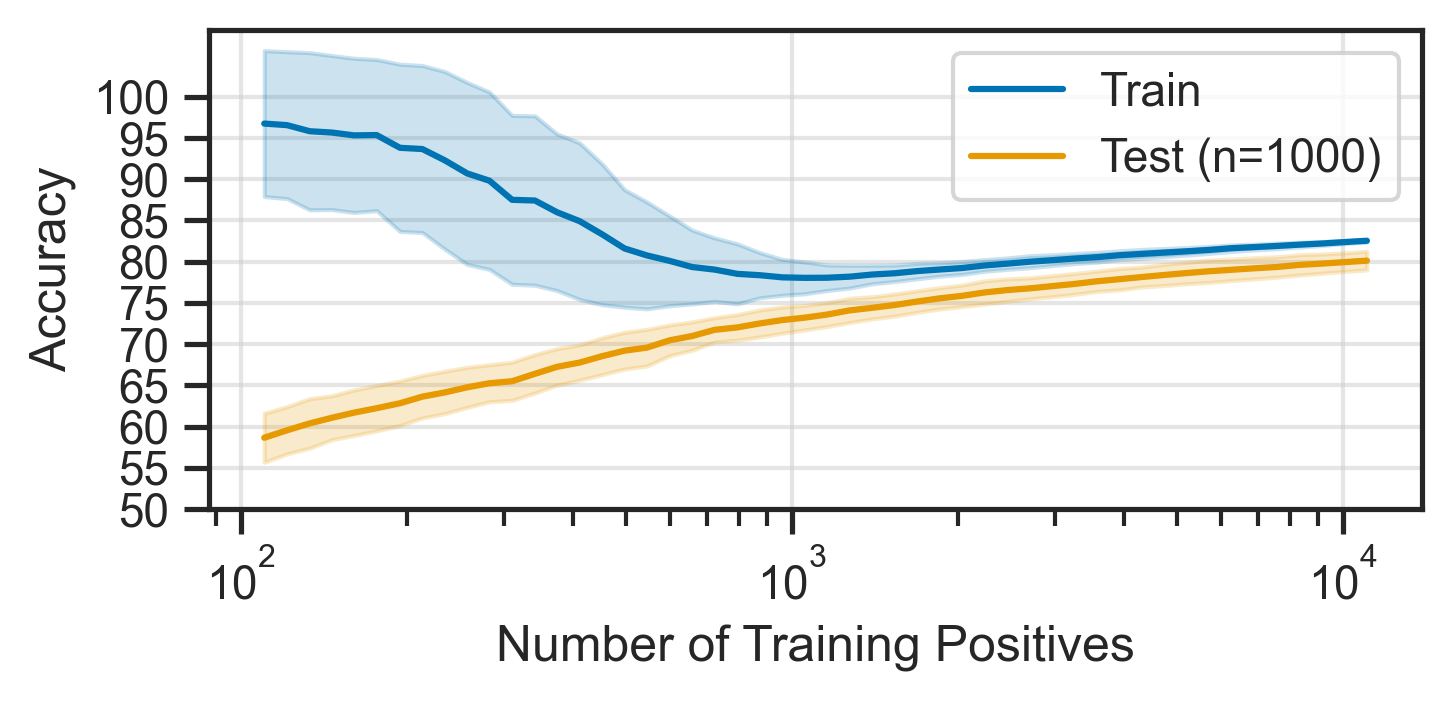

In [26]:
fig, ax = plt.subplots(1, 1, figsize=(5, 2.5), dpi=300)
plt.grid(alpha=0.5)
sns.lineplot(x="TrainSize", y="Accuracy", 
             data=accuracy[accuracy['Train/Test'] == 'Train'], 
             label='Train', ci='sd')
sns.lineplot(x="TrainSize", y="Accuracy", 
             data=accuracy[accuracy['Train/Test'] == 'Test'], 
             label=f'Test (n={len(X_test)})', ci='sd')
ax.set_xlabel('Number of Training Positives')
ax.set_xscale('log')

plt.tight_layout()
ax.set_yticks(np.arange(50,101,5))
# plt.savefig('classiferror1.pdf')
plt.show()

In [14]:
dPCR_mixture.groupby(['LoadedPanels', 'MeltLabels']).size().reset_index().rename(columns={0:'count'})

NameError: name 'dPCR_mixture' is not defined

## Distribution of Targets in Loaded Panels (for MCA and ACA)
- mixture MeltLabels vs test on mixture LoadedPanels
- training pure MeltLabels vs test on mixture LoadedPanels

In [ ]:
all_mapping = OrderedDict({'NDM': 0, 
                           'VIM': 1, 
                           'KPC': 2,
                           'VIM_NDM': 3, 
                           'NDM_KPC': 4,
                           'VIM_KPC': 5, 
                           'VIM_NDM_KPC': 6})

X_train = dPCR_pure.filter(like='Cycle').values
y_train = label_to_numeric(dPCR_pure.MeltLabels.values, all_mapping)

X_test = dPCR_mixture.filter(like='Cycle').values
y_test_LP = label_to_numeric(dPCR_mixture.LoadedPanels.values, all_mapping)
y_test_MC = label_to_numeric(dPCR_mixture.MeltLabels.values, all_mapping)



N_NEIGHS = 10

neigh = KNeighborsClassifier(n_neighbors=N_NEIGHS)

neigh.fit(X_train, y_train)

y_pred = neigh.predict(X_test)

def mapLatex(l):
    l_new = []
    for i in l:
        if i=='NDM':
            l_new.append('$bla_{NDM}$')
        elif i=='VIM':
            l_new.append('$bla_{VIM}$')
        elif i=='KPC':
            l_new.append('$bla_{KPC}$')
        elif i=='NDM_KPC':
            l_new.append(' $bla_{NDM}$\n+$bla_{KPC}$')
        elif i=='VIM_NDM':
            l_new.append(' $bla_{NDM}$\n+$bla_{VIM}$')
        elif i=='VIM_KPC':
            l_new.append(' $bla_{VIM}$\n+$bla_{KPC}$')
        elif i=='VIM_NDM_KPC':
            l_new.append(' $bla_{NDM}$\n+$bla_{VIM}$\n+$bla_{KPC}$')
            
    return l_new

fig, ax = plt.subplots(1, 2, figsize=(12, 6), dpi=300)
utils.my_plot_confusion_matrix2(y_true=y_test_LP, 
                  y_pred=y_test_MC, 
                  classes=mapLatex(all_mapping.keys()),
                  mask=np.hstack((np.vstack((np.eye(3, 3), 1-np.fliplr(np.eye(3, 3)), np.ones((1, 3)))), np.zeros((7, 4)) )),
                  test_classes=mapLatex(all_mapping.keys()),#[k.replace('_', '\n') for k in all_mapping.keys()],
                  title=False,
                  ax=ax[0])

plt.xticks(rotation=0)
ax[0].set_xlabel('TRUE (MCA)')
ax[0].set_ylabel('LOADED PANEL')
ax[0].set_title('')

utils.my_plot_confusion_matrix2(y_true=y_test_LP, 
                  y_pred=y_pred, 
                  classes=mapLatex(pure_mapping.keys()),
                  mask=np.vstack((np.eye(3, 3), 1-np.fliplr(np.eye(3, 3)), np.ones((1, 3)))) ,
                  test_classes=mapLatex(all_mapping.keys()),#[k.replace('_', '\n') for k in all_mapping.keys()],
                  title=False,
                  ax=ax[1])

ax[1].set_xlabel('PREDICTED (ACA)')
ax[1].set_ylabel('LOADED PANEL')
ax[1].set_title('')

plt.tight_layout()
plt.show()

## Train on Pure, Test on All Combinations (Different Digital Chip)
- training pure MeltLabels vs test on mixture MeltLabels

In [ ]:
all_mapping = OrderedDict({'NDM': 0, 
                           'VIM': 1, 
                           'KPC': 2,
                           'VIM_NDM': 3, 
                           'NDM_KPC': 4,
                           'VIM_KPC': 5, 
                           'VIM_NDM_KPC': 6})

X_train = dPCR_pure.filter(like='Cycle').values
y_train = label_to_numeric(dPCR_pure.MeltLabels.values, all_mapping)

X_test = dPCR_mixture.filter(like='Cycle').values
y_test = label_to_numeric(dPCR_mixture.MeltLabels.values, all_mapping)

N_NEIGHS = 10

neigh = KNeighborsClassifier(n_neighbors=N_NEIGHS)

neigh.fit(X_train, y_train)

y_pred = neigh.predict(X_test)

fig, ax = plt.subplots(1, 1, figsize=(5, 5), dpi=100)
                          
cm = utils.my_plot_confusion_matrix2(y_true=y_test,
                               y_pred=y_pred, 
                               classes=mapLatex(pure_mapping.keys()),
                               mask=np.vstack((np.eye(3, 3), np.zeros((4, 3)))) ,
                               test_classes=mapLatex(all_mapping.keys()),#test_classes=[k.replace('_', '\n') for k in all_mapping.keys()],
                               title=False,
                               ax=ax)

ax.set_title(f'TESTING \n{ax.get_title()}\nAccuracy: {100*np.mean(y_test == y_pred):.3f}')

# print(100*np.mean(y_test == y_pred))

plt.tight_layout()
plt.show()

In [ ]:
all_mapping = OrderedDict({'NDM': 0, 
                           'VIM': 1, 
                           'KPC': 2,
                           'VIM_NDM': 3, 
                           'NDM_KPC': 4,
                           'VIM_KPC': 5, 
                           'VIM_NDM_KPC': 6})

X = dPCR_pure.filter(like='Cycle').values
y = label_to_numeric(dPCR_pure.MeltLabels.values, all_mapping)

X_test = dPCR_mixture.filter(like='Cycle').values
y_test = label_to_numeric(dPCR_mixture.MeltLabels.values, all_mapping)

n_splits = 100
n_train_sizes = 50

train_size = np.linspace(0.01, 0.99, num=n_train_sizes)
train_size = np.logspace(-2, 0, num=n_train_sizes)

accuracy = pd.DataFrame(columns = ['TrainSize', 'Train/Test', 'Accuracy', 'SplitID'])

train_acc = np.zeros((n_splits, n_train_sizes))
test_acc = np.zeros((n_splits, n_train_sizes))

for size in tqdm(train_size, desc='Train Size Split'):

    neigh = KNeighborsClassifier(n_neighbors=N_NEIGHS)

    sss = StratifiedShuffleSplit(n_splits=n_splits, test_size=3, random_state=0)

    for split_id, (train_index, test_index) in enumerate(sss.split(X, y)):
        
        X_train, _ = X[train_index], _
        y_train, _ = y[train_index].ravel(), _
        
        X_train = X_train[:int(len(X_train)*size), :]
        y_train = y_train[:int(len(y_train)*size)]

        neigh.fit(X_train, y_train)
        
        new_row = pd.DataFrame([{'TrainSize': len(X_train), 
                                    'Train/Test': 'Train',
                                    'Accuracy': 100*np.mean(y_train == neigh.predict(X_train)), 
                                    'SplitID': split_id}])
        accuracy = pd.concat([accuracy, new_row], ignore_index=True)


        new_row = pd.DataFrame([{'TrainSize': len(X_train), 
                                    'Train/Test': 'Test',
                                    'Accuracy': 100*np.mean(y_test == neigh.predict(X_test)), 
                                    'SplitID': split_id}])
        accuracy = pd.concat([accuracy, new_row], ignore_index=True)
        
        new_row = pd.DataFrame([{'TrainSize': len(X_train), 
                                    'Train/Test': 'Test_Pure',
                                    'Accuracy': 100*np.mean(y_test[y_test<3] == neigh.predict(X_test[y_test<3])), 
                                    'SplitID': split_id}])
        accuracy = pd.concat([accuracy, new_row], ignore_index=True)

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(5, 2.5), dpi=300)

sns.lineplot(x="TrainSize", y="Accuracy", 
             data=accuracy[accuracy['Train/Test'] == 'Train'], label='Train', ci='sd')
sns.lineplot(x="TrainSize", y="Accuracy", 
             data=accuracy[accuracy['Train/Test'] == 'Test'], label=f'Test All (n={len(X_test)})', ci='sd')
sns.lineplot(x="TrainSize", y="Accuracy", 
             data=accuracy[accuracy['Train/Test'] == 'Test_Pure'], label=f'Test Pure (n={len(X_test[y_test<3])})', ci='sd')

ax.set_xlabel('Number of Training Positives')
ax.set_ylim((80, 100))
ax.set_xscale('log')

accuracy.to_csv('Data/accuracy2.csv')

plt.tight_layout()
# plt.savefig('classiferror2.pdf')
plt.show()